**소프트 백터 머신**

**서포트 벡터 머신(support vector machine)** 은 매우 강력함

선형,비선형 분류, 회귀, 특이치에도 사용할 수 있는 다목적 머신러닝 모델임.

# 설정

이 프로젝트를 실행하려면 파이썬 3.7 이상이 필요함:

In [1]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 1.0.1 이상이 필요함:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기를 정의함:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지를 저장할 경로와 함수를 정의함:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
from sklearn import set_config

set_config(display="text")

# 선형 SVM 분류

SVM 분류기는 분류기를 클래스 사이에 가장 폭이 넓은 도록를 찾는 다는 것이라고 볼 수 있음. 그렇기 때문에 **라지 마진 분류(large margin classification)** 이라고도 불림

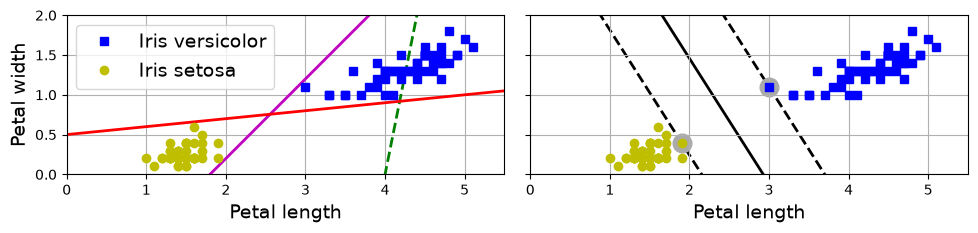

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM 분류 모델
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(X, y)

# 나쁜 모델
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

save_fig("large_margin_classification_plot")
plt.show()

도로 바까톡에 훈련 샘플을 추가해도 결정 경계에는 전혀 영향으 ㄹ미치지 않음. 도로 경계에 위치한 샘플에 의해 전적으로 결정됨. 이런 샘플을 **서포트 벡터 (support vector)** 라고 부름.

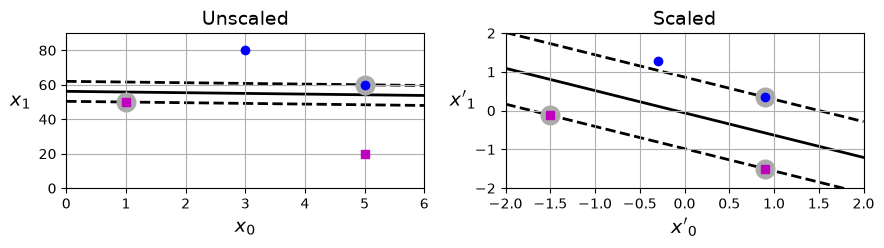

In [7]:
from sklearn.preprocessing import StandardScaler

Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100).fit(Xs, ys)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf_scaled = SVC(kernel="linear", C=100).fit(X_scaled, ys)

plt.figure(figsize=(9, 2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$")
plt.ylabel("$x_1$    ", rotation=0)
plt.title("Unscaled")
plt.axis([0, 6, 0, 90])
plt.grid()

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf_scaled, -2, 2)
plt.xlabel("$x'_0$")
plt.ylabel("$x'_1$  ", rotation=0)
plt.title("Scaled")
plt.axis([-2, 2, -2, 2])
plt.grid()

save_fig("sensitivity_to_feature_scales_plot")
plt.show()

## 소프트 마진 분류

**하드 마진 분류기 (hard margin classification)** : 모든 샘플이 도로 바깥쪽에 올바르게 분류되는 분류기

문제점 2가지: 
1. 데이터가 선형적으로 구분될 수 있어야 제대로 동작됨.
2. 이상치에 민감함

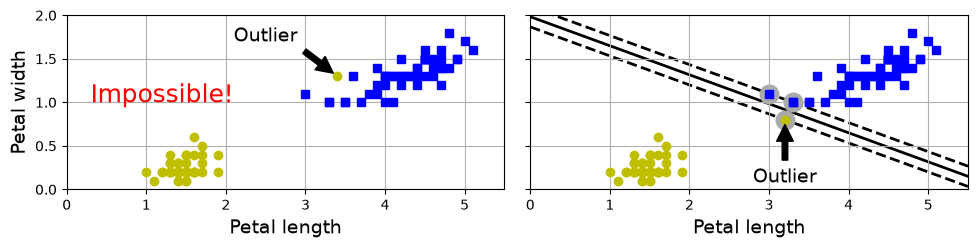

In [8]:
X_outliers = np.array([[3.4, 1.3], [3.2, 0.8]])
y_outliers = np.array([0, 0])
Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)
yo1 = np.concatenate([y, y_outliers[:1]], axis=0)
Xo2 = np.concatenate([X, X_outliers[1:]], axis=0)
yo2 = np.concatenate([y, y_outliers[1:]], axis=0)

svm_clf2 = SVC(kernel="linear", C=10**9)
svm_clf2.fit(Xo2, yo2)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(Xo1[:, 0][yo1==1], Xo1[:, 1][yo1==1], "bs")
plt.plot(Xo1[:, 0][yo1==0], Xo1[:, 1][yo1==0], "yo")
plt.text(0.3, 1.0, "Impossible!", color="red", fontsize=18)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.annotate(
    "Outlier",
    xy=(X_outliers[0][0], X_outliers[0][1]),
    xytext=(2.5, 1.7),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

plt.sca(axes[1])
plt.plot(Xo2[:, 0][yo2==1], Xo2[:, 1][yo2==1], "bs")
plt.plot(Xo2[:, 0][yo2==0], Xo2[:, 1][yo2==0], "yo")
plot_svc_decision_boundary(svm_clf2, 0, 5.5)
plt.xlabel("Petal length")
plt.annotate(
    "Outlier",
    xy=(X_outliers[1][0], X_outliers[1][1]),
    xytext=(3.2, 0.08),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

save_fig("sensitivity_to_outliers_plot")
plt.show()

이런 문제를 피가 위해서 좀 더 유연하 모델을 사용해야함.

**소프트 마진 분류기 (soft margin classification)** : 도로의 폭을 가능한 넓게 유지하는 것과 **마진 오류(margin error)** 상에 적저한 균형을 잡아주는 분류기

사이킷런의 SVM 모델을 만들 때 규제 하이퍼파라미터 C를 포함하여 여러 하이퍼파라미터를 지정 할 수 있음.

C를 줄이면 도로가 더 커지지만 더 많은 마진 오류가 발생함. 이를 다르게 말하면, 도로를 지지하는 샘플이 더 많아지므로 과대적합의 위험이 줄어듬. 하지만 지나치게 줄이면 과소적합됨.

In [9]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2).to_numpy()  # Iris virginica

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=1, dual=True, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, dual=True, random_state=42))])

In [10]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [11]:
svm_clf.decision_function(X_new)

array([ 0.66163411, -0.22036063])

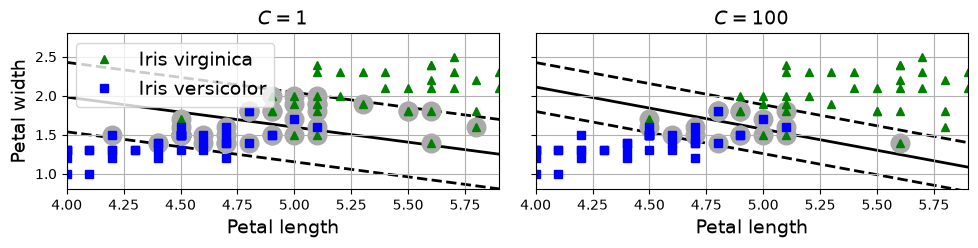

In [12]:
scaler = StandardScaler()
svm_clf1 = LinearSVC(C=1, max_iter=10_000, dual=True, random_state=42)
svm_clf2 = LinearSVC(C=100, max_iter=10_000, dual=True, random_state=42)

scaled_svm_clf1 = make_pipeline(scaler, svm_clf1)
scaled_svm_clf2 = make_pipeline(scaler, svm_clf2)

scaled_svm_clf1.fit(X, y)
scaled_svm_clf2.fit(X, y)

# 스케일링되지 않은 파라미터로 변환
b1 = svm_clf1.decision_function([-scaler.mean_ / scaler.scale_])
b2 = svm_clf2.decision_function([-scaler.mean_ / scaler.scale_])
w1 = svm_clf1.coef_[0] / scaler.scale_
w2 = svm_clf2.coef_[0] / scaler.scale_
svm_clf1.intercept_ = np.array([b1])
svm_clf2.intercept_ = np.array([b2])
svm_clf1.coef_ = np.array([w1])
svm_clf2.coef_ = np.array([w2])

# 서포트 벡터 찾기(LinearSVC는 이 작업을 자동으로 수행하지 않음)
t = y * 2 - 1
support_vectors_idx1 = (t * (X.dot(w1) + b1) < 1).ravel()
support_vectors_idx2 = (t * (X.dot(w2) + b2) < 1).ravel()
svm_clf1.support_vectors_ = X[support_vectors_idx1]
svm_clf2.support_vectors_ = X[support_vectors_idx2]

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Iris virginica")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Iris versicolor")
plot_svc_decision_boundary(svm_clf1, 4, 5.9)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.title(f"$C = {svm_clf1.C}$")
plt.axis([4, 5.9, 0.8, 2.8])
plt.grid()

plt.sca(axes[1])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plot_svc_decision_boundary(svm_clf2, 4, 5.99)
plt.xlabel("Petal length")
plt.title(f"$C = {svm_clf2.C}$")
plt.axis([4, 5.9, 0.8, 2.8])
plt.grid()

save_fig("regularization_plot")
plt.show()

# 비선형 SVM 분류 

비선형 데이터셋을 다루는 한 가지 방법은 다항 특성과 같은 특성을 추가하는 것.

아래는 특성이 $x_1$하나뿐인 데이터셋과, 특성이 $x_2=(x_1)^2$를 추가하여 만든 그래프를 비교하는 코드 : 

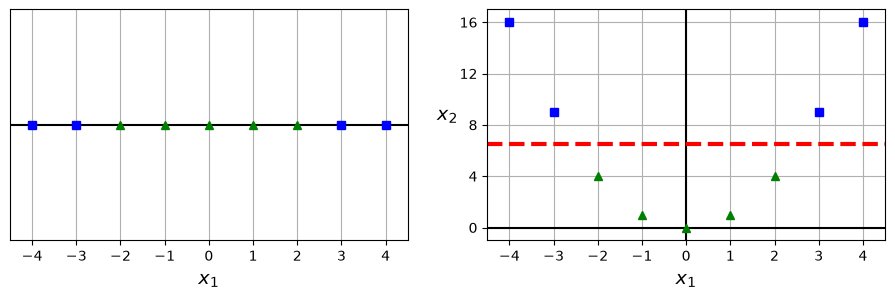

In [13]:
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel("$x_1$")
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$  ", rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

plt.subplots_adjust(right=1)

save_fig("higher_dimensions_plot", tight_layout=False)
plt.show()

이를 구현하기 위해 `PolynomiaFeatures`변환기와 `StandardScaler`,`LinearSVC`를 연결하여 파이프라인을 만듦. 

이를 moons 데이터셋에 적용. 이 데이터셋은 마주보는 두개의 초승달 모양으로 데이터 포인트가 놓여 있는 이진 분류를 위한 작은 데이터셋임. 

In [14]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, dual=True, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, dual=True, max_iter=10000, random_state=42))])

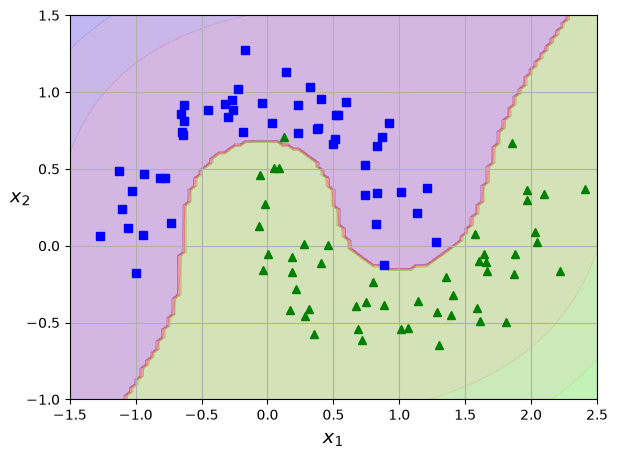

In [15]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

save_fig("moons_polynomial_svc_plot")
plt.show()

## 다항식 커널

다항 특성을 추가하는 것엔 낮은 차수일때는 복잡한 데이터셋을 표현하지 못한다거나, 높은 차수의 다항식은 시간이 오래 걸린다는 단점이 있음.

**커널 트릭 (kernel trick)** : 실제로는 특성을 추가하지 않으면서 매우 높은 차수의 다항 특성을 많이 추가한 것과 같은 결과를 얻게해주는 수학적 기교. 

In [16]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

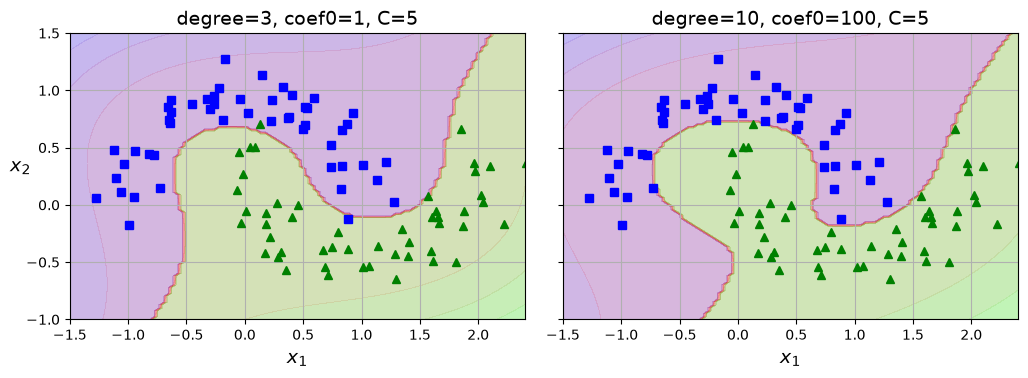

In [17]:
poly100_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=10, coef0=100, C=5)
)
poly100_kernel_svm_clf.fit(X, y)

fig, axes = plt.subplots(ncols=2, figsize=(10.5, 4), sharey=True)

plt.sca(axes[0])
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=3, coef0=1, C=5")

plt.sca(axes[1])
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=10, coef0=100, C=5")
plt.ylabel("")

save_fig("moons_kernelized_polynomial_svc_plot")
plt.show()

## 유사성 특성

비선형 특성을 다루는 또 다른 방법 : 각 샘플이 특정 **랜드마크** 와 얼마나 닮았는지 **유사도 함수 (similarity function)** ㄹ 계산한 특성을 추가하는 것.

앞서 본 1차원 데이터셋에 두 개의 랜드마크 $x_1 = -2$와 $x_1 = -1$를 추가하고 $\gamma=0.3$인 가우스 **방사 기저 함수 (radial basis function, RBF)** 를 유사도 함수로 정의

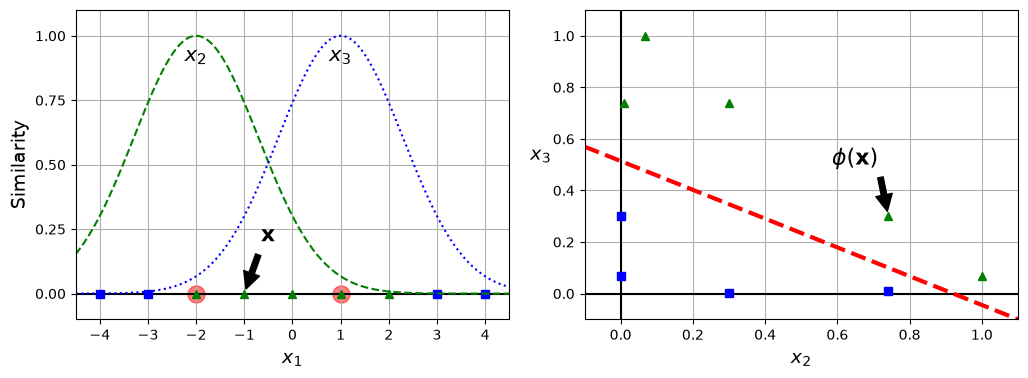

In [18]:
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark, axis=1)**2)

gamma = 0.3

x1s = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
x2s = gaussian_rbf(x1s, -2, gamma)
x3s = gaussian_rbf(x1s, 1, gamma)

XK = np.c_[gaussian_rbf(X1D, -2, gamma), gaussian_rbf(X1D, 1, gamma)]
yk = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10.5, 4))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.scatter(x=[-2, 1], y=[0, 0], s=150, alpha=0.5, c="red")
plt.plot(X1D[:, 0][yk==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][yk==1], np.zeros(5), "g^")
plt.plot(x1s, x2s, "g--")
plt.plot(x1s, x3s, "b:")
plt.gca().get_yaxis().set_ticks([0, 0.25, 0.5, 0.75, 1])
plt.xlabel("$x_1$")
plt.ylabel("Similarity")
plt.annotate(
    r'$\mathbf{x}$',
    xy=(X1D[3, 0], 0),
    xytext=(-0.5, 0.20),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
    fontsize=16,
)
plt.text(-2, 0.9, "$x_2$", ha="center", fontsize=15)
plt.text(1, 0.9, "$x_3$", ha="center", fontsize=15)
plt.axis([-4.5, 4.5, -0.1, 1.1])

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(XK[:, 0][yk==0], XK[:, 1][yk==0], "bs")
plt.plot(XK[:, 0][yk==1], XK[:, 1][yk==1], "g^")
plt.xlabel("$x_2$")
plt.ylabel("$x_3$  ", rotation=0)
plt.annotate(
    r'$\phi\left(\mathbf{x}\right)$',
    xy=(XK[3, 0], XK[3, 1]),
    xytext=(0.65, 0.50),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
    fontsize=16,
)
plt.plot([-0.1, 1.1], [0.57, -0.1], "r--", linewidth=3)
plt.axis([-0.1, 1.1, -0.1, 1.1])

plt.subplots_adjust(right=1)

save_fig("kernel_method_plot")
plt.show()

## 가우스 RBF 커널

다항 특성 방식과 마찬가리조 유사도 특성 방식도 머신러닝 알고리즘에 유용하게 사용될 수 있음. 추가 특성을 모두 계산하려면 연산 비용이 많이 듦. 여기서 커널 트릭을 사용해 유산도 특성을 많이 추가하는 것과 같은 비슷한 결과를 얻을 수 있음.

가우스 RBF 커널을 사용한 SVC 모델 :

In [19]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel="rbf", gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

왼쪽 아래의 그래프에 이 모델을 나타냄. 다른 그래프들은 하이퍼파라미터 gamma와 C를 바꾸어 훈련시킨 모델임.

- 큰 gamma : 종 모양 그래프가 좁아져 각 샘플의 영향 범위가 작아짐. 결정 경계가 조금 더 불규칙해지고 각 샘플을 따라 구불구불하게 휘어짐
- 작은 gamma : 넓은 종 모양 그래프를 만들며 샘플이 넓은 범위에 걸쳐 영향을 줌. 경정 경계가 더 부드러워짐. 

결국 하이퍼파라미터 $\gamma$가 규제 역할을 함. 모델이 과대적합일 경우에는 감소시키고 과소 적합일때는 증가시켜야함.

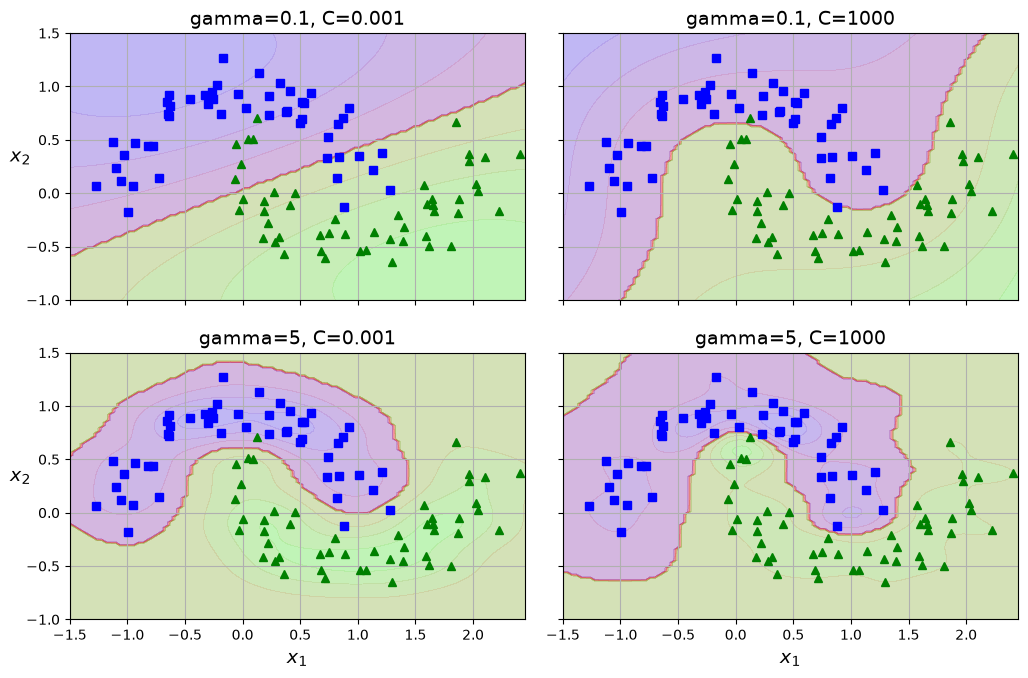

In [20]:

from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 5
C1, C2 = 0.001, 1000
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

svm_clfs = []
for gamma, C in hyperparams:
    rbf_kernel_svm_clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma=gamma, C=C)
    )
    rbf_kernel_svm_clf.fit(X, y)
    svm_clfs.append(rbf_kernel_svm_clf)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10.5, 7), sharex=True, sharey=True)

for i, svm_clf in enumerate(svm_clfs):
    plt.sca(axes[i // 2, i % 2])
    plot_predictions(svm_clf, [-1.5, 2.45, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.45, -1, 1.5])
    gamma, C = hyperparams[i]
    plt.title(f"gamma={gamma}, C={C}")
    if i in (0, 1):
        plt.xlabel("")
    if i in (1, 3):
        plt.ylabel("")

save_fig("moons_rbf_svc_plot")
plt.show()

다른 커널도 있지만 거의 사용되지 않음. 어떤 커널은 특정 데이터 구조에 특화되어 있음. **문자열 커널(string kernel)** 이 가끔 텍스트나 DNA 서열을 분류할 때 사용됨.

## 계산 복잡도

`LinearSVC`파이썬 클래스는 선형 SVM을 위한 최적화된 알고리즘을 구현한 `liblinear`라이브러리를 기반을 함. 이 알고리즘의 훈련시간 복잡도는 대략 $O(m \cdot n)$ 정도 임. 정밀도르 ㄹ높이면 알고리즘의 수행 시간은 길어짐 이는 허용 오차 하이퍼파라미터 $\epsilon$으로 조절함. 

`SVM`는 커널 트릭 알고리즘을 구현한 `libsvm`라이브러리를 기반으로 함. 훈련의 시간복잡도는 보통 $O(m^2 \cdot n)$과 $O(m^3 \cdot n)$사이임. 불행하게도 이는 훈련 샘플 수가 커지면 엄청 느려진다는 것을 의미함. 

따라서 중소규모의 비선형 훈련 세트에 이 알고리즘이 맞음 하지만 특성의 수에 대해서는, 특히 **희소 특성(sparse feature)**인 경우에는 잘 확장됨. 이런 경우 알고리즘의 성능이 샘플이 가진 0이 아닌 특성의 평균 수에 거의 비례함.

`SGDClassifier` 클래스는 기본적으로 라지 마진 분류를 수행하며 하이퍼파라미터, 특히 규제 하이퍼파라미터와 `learning_rate`를 조정하여 선형 SVM과 유사한 결과를 생성할 수 있음. 훈련을 위해 점진적 학습이 가능하고 메모리를 거의 사용하지 않는 확률적 경사 하강법을 사용하므로 RAM에 맞지 않는 대규모 데이터셋에서 모델을 훈련할 수 있음. 또한 계산 복잡도가 $O(M \cdot n)$ 이므로 확장성이 매우 뛰어남.

SVM 분류를 위한 사이킷런 파이썬 클래스 비교:

|파이써 클래스|시간 복잡도|외부 메모리 학습 지원|스케일 조정의 필요성|커널 트릭|
|---|---|---|---|---|
|LinearSVC|$O(m \cdot n)$|No|Yes|No|
|SVC|$O(m^2 \cdot n) \sim O(m^3 \cdot n)$|No|Yes|Yes|
|SGDClassifier|O(m \cdot n)|Yes|Yes|No|

# SVM 회귀

SVM을 분류가 아니라 회귀에 적용하는 방법은 목표를 조금 바꾸는 것임. 일정한 마진오류 안에서 두 클래스 간의 도로 폭이 간으한 최대가 되도록 하는 대신, SVM 회귀는 제한된 마진 오류 안에서 도로 안에 가능한 많은 샘플이 들어가도록 학습함. 도로의 폭으 하이퍼파라미터 $\epsilon$으로 조절함. 

In [21]:
from sklearn.svm import LinearSVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(50)

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, epsilon=0.5, random_state=42))])

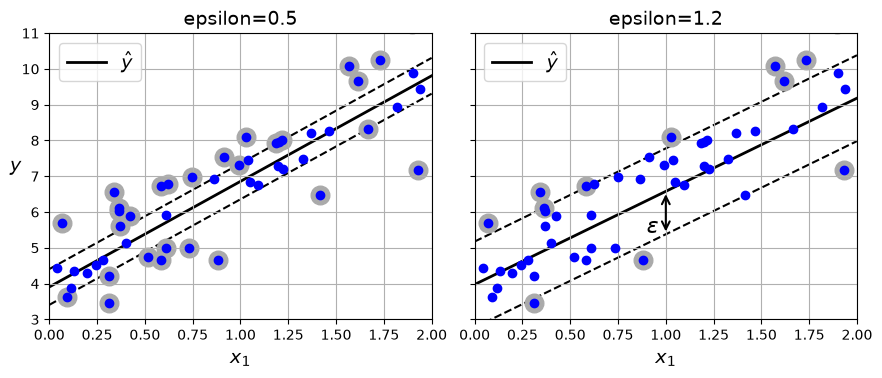

In [22]:
def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    epsilon = svm_reg[-1].epsilon
    off_margin = np.abs(y - y_pred) >= epsilon
    return np.where(off_margin)[0]

def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    epsilon = svm_reg[-1].epsilon
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$", zorder=-2)
    plt.plot(x1s, y_pred + epsilon, "k--", zorder=-2)
    plt.plot(x1s, y_pred - epsilon, "k--", zorder=-2)
    plt.scatter(X[svm_reg._support], y[svm_reg._support], s=180,
                facecolors='#AAA', zorder=-1)   
    plt.plot(X, y, "bo")
    plt.xlabel("$x_1$")
    plt.legend(loc="upper left")
    plt.axis(axes)

svm_reg2 = make_pipeline(StandardScaler(),
                         LinearSVR(epsilon=1.2, dual=True, random_state=42))
svm_reg2.fit(X, y)

svm_reg._support = find_support_vectors(svm_reg, X, y)
svm_reg2._support = find_support_vectors(svm_reg2, X, y)

eps_x1 = 1
eps_y_pred = svm_reg2.predict([[eps_x1]]).item()


fig, axes = plt.subplots(ncols=2, figsize=(9, 4), sharey=True)
plt.sca(axes[0])
plot_svm_regression(svm_reg, X, y, [0, 2, 3, 11])
plt.title(f"epsilon={svm_reg[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.sca(axes[1])
plot_svm_regression(svm_reg2, X, y, [0, 2, 3, 11])
plt.title(f"epsilon={svm_reg2[-1].epsilon}")
plt.annotate(
        '', xy=(eps_x1, eps_y_pred), xycoords='data',
        xytext=(eps_x1, eps_y_pred - svm_reg2[-1].epsilon),
        textcoords='data', arrowprops={'arrowstyle': '<->', 'linewidth': 1.5}
    )
plt.text(0.90, 5.4, r"$\epsilon$", fontsize=16)
plt.grid()
save_fig("svm_regression_plot")
plt.show()

$\epsilon$을 줄이면 서포트 벡터의 수가 늘어나서 모델이 규제됨. 마진 안에서는 샘플이 추가 되어도 모델의 예측에는 영향이 없음. 그래서 이 모델을 **$\boldsymbol{\epsilon}$에 민감하지 않다($\epsilon$-insensitive)** 고 말함.

사이킷런의 `LinearSVR`을 사용해 선형 SVM 회귀를 적용 : 

In [23]:
from sklearn.svm import SVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

비선형 회귀 작업을 처리하려면 커널 SVM 모델을 사용해야함. 임의의 2차 방정식 형태의 훈련 세트에 2차 다항 커널을 사요한 SVM 회귀를 보여줌. 외쪽 그래프는 규제가 약간 있고(작은 C), 오른쪽 그래프는 규제가 훨씬 작음(큰 C)

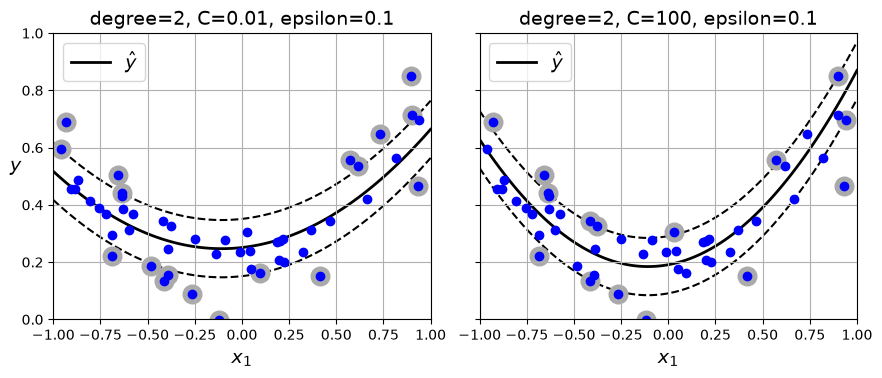

In [24]:
svm_poly_reg2 = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=100))
svm_poly_reg2.fit(X, y)

svm_poly_reg._support = find_support_vectors(svm_poly_reg, X, y)
svm_poly_reg2._support = find_support_vectors(svm_poly_reg2, X, y)

fig, axes = plt.subplots(ncols=2, figsize=(9, 4), sharey=True)
plt.sca(axes[0])
plot_svm_regression(svm_poly_reg, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svm_poly_reg[-1].degree}, "
          f"C={svm_poly_reg[-1].C}, "
          f"epsilon={svm_poly_reg[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()

plt.sca(axes[1])
plot_svm_regression(svm_poly_reg2, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svm_poly_reg2[-1].degree}, "
          f"C={svm_poly_reg2[-1].C}, "
          f"epsilon={svm_poly_reg2[-1].epsilon}")
plt.grid()
save_fig("svm_with_polynomial_kernel_plot")
plt.show()

`SVR`은 SVC의 회귀 버전이고 `LinearSVR`은 LinearSVC의 회귀 버전임. `LinerSVC`의 회귀 버전임. `LinearSVR`은 필요한 시간이 훈련 세트의 크기에 비례해서 선형적으로 늘어남. 하지만 `SVR`은 훈련 세트가 커지면 훨ㅆ니 느려짐.

# SVM 이론

선형 SVM 분류기 모델은 단순히 결정 함수  $\boldsymbol{\theta^{\top}\mathbf{x}}=\theta_{0}x_{0}+\cdots+\theta_{n}x_{n}$을 계산하여 새로운 샘플 $\mathbf{x}$의 클래스를 예측함. 

결과값이 0보다 크면 예측된 클래스 $\hat{y}$은 양성 클래스 (1)이 됨. 그렇지 않으면 음성 클래스 (0)이 됨.

따라서 선형 SVM 분류ㅣ로 예측하는 것은 매우 간단함.

훈련에서는 마진 오류 횟수를 제한하면서 도로르 ㄹ가능한 얿게 만드는 가중치 벡터 $\mathbf{w}$를 더 작게 만들어야함.

2D로 시각화했을때. 도로의 경계를 경정 함수가 -1또는 +1 포인트로 정의함. 왼쪼 ㄱ그래프에서는 가중치 $w_1$은 1이므로 $w_1x_1=-1$또는 +1인 포인트는 $x_1 = -1$과 +1임. 따라서 마진의 크기는 2임. 

오른쪽그래프에서는 가중치는  0.5이므로 $w_1x_1 = -1$ 또는 +1인 점은 $x_1 = -2$와 +2임. 따라서 마진의 크기는 4임

결국 $\mathbf{w}$를 가능한 작게 유지해야함. 편향 $b$는 마진의 크기에 영향을 미치지 않음.

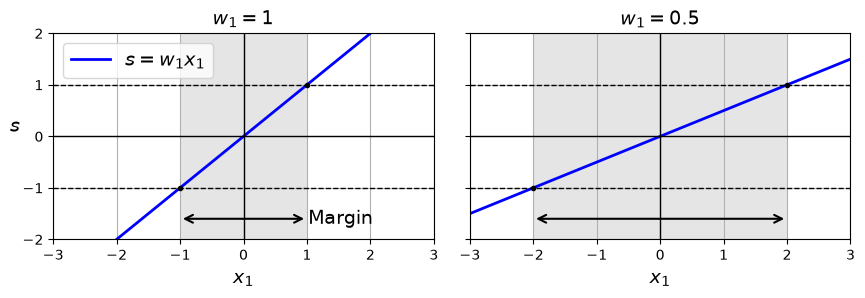

In [25]:
import matplotlib.patches as patches

def plot_2D_decision_function(w, b, ylabel=True, x1_lim=[-3, 3]):
    x1 = np.linspace(x1_lim[0], x1_lim[1], 200)
    y = w * x1 + b
    half_margin = 1 / w

    plt.plot(x1, y, "b-", linewidth=2, label=r"$s = w_1 x_1$")
    plt.axhline(y=0, color='k', linewidth=1)
    plt.axvline(x=0, color='k', linewidth=1)
    rect = patches.Rectangle((-half_margin, -2), 2 * half_margin, 4,
                             edgecolor='none', facecolor='gray', alpha=0.2)
    plt.gca().add_patch(rect)
    plt.plot([-3, 3], [1, 1], "k--", linewidth=1)
    plt.plot([-3, 3], [-1, -1], "k--", linewidth=1)
    plt.plot(half_margin, 1, "k.")
    plt.plot(-half_margin, -1, "k.")
    plt.axis(x1_lim + [-2, 2])
    plt.xlabel("$x_1$")
    if ylabel:
        plt.ylabel("$s$", rotation=0, labelpad=5)
        plt.legend()
        plt.text(1.02, -1.6, "Margin", ha="left", va="center", color="k")

    plt.annotate(
        '', xy=(-half_margin, -1.6), xytext=(half_margin, -1.6),
        arrowprops={'ec': 'k', 'arrowstyle': '<->', 'linewidth': 1.5}
    )
    plt.title(f"$w_1 = {w}$")

fig, axes = plt.subplots(ncols=2, figsize=(9, 3.2), sharey=True)
plt.sca(axes[0])
plot_2D_decision_function(1, 0)
plt.grid()
plt.sca(axes[1])
plot_2D_decision_function(0.5, 0, ylabel=False)
plt.grid()
save_fig("small_w_large_margin_plot")
plt.show()

마진 오류도 피하는 법 :  결정 함수가 모든 양성 훈련 샘플에서는 1보다 커야 하고 음성 훈련 샘플에서는 -1보다 작아야함. 음성 샘플($y^{(i)} = 0$)일 떄 $t^{(i)} = -1$로, 양성 샘플은 $y^{(i)} = 1$일 때, $t^{(i)} = 1$로 정의하면 앞서 말한 제약 조건을 모든 샘플에서 $t^{(i)}(\mathbf{w}^{\top}\mathbf{x}^{(i)} + b) \geq 1$로 표현 할 수 있음.

그러므로 하드 마진 선형 SVM 분류기의 목적함수를 제약이 있는 최적화문제로 표현할 수 있음.

하드 마진 선형 SVM 분류기의 목적 함수 : 
$$
\underset{\mathbf{w}, b}{\mathrm{minimize}} \frac{1}{2}\mathbf{w}^{\top}\mathbf{w}
$$
[조건]  $i = 1,2, \cdots , m$일 때  $t^{(i)}(\mathbf{w}^{\top}\mathbf{x}^{(i)} + b) \geq 1$

소프트 마진 분류기의 목적 함수를 구성하려면 각 샘플에 대해 **슬랙 변수(slack variable)** $\zeta^{(i)} \geq 0$ 을 도입해야함

$\zeta^{(i)}$는 $i$번째 샘프링 얼마나 마진을 위반할지 정함. 이 문제는 두 개의 상충되는 목표르 가짐. 마진의 오류를 최소화하기 위해 가능한 한 슬랙 변수의 값을 작게 만드는것과 마진을 크게하기 위해 $\frac{1}{2}\mathbf{w}^{\top}\mathbf{w}$를 가능한 한 작게 만드는 것. 여깃에서 하이퍼파라미터 C가 등장함. C는 두 목표 사이의 트레이드 오프를 정의함.

소프트 마진 선형 SVM 분류기의 목적 함수 :
$$
\underset{\mathbf{w}, b, \zeta}{\mathrm{minimize}} 
= \frac{1}{2}\mathbf{w}^{\top}\mathbf{w} + C\sum_{i=1}^{m} \zeta^{(i)}
$$
[조건]  $i = 1,2, \cdots , m$일 때  $t^{(i)}(\mathbf{w}^{\top}\mathbf{x}^{(i)} + b) \geq 1-\zeta^{(i)}$이고 $\zeta^{(i)} \geq 0$

하드 마진과 소프트마진 문제는 모두 선형적인 제약 조건이 있는 볼록 함수의 이차 최적화 문제임. 이런 무제를 **콰드라틱 프로그래밍(QP)** 문제라고 함.

SVM을 훈련하는 한 가지 방법은 QP 솔버(QP solver)무를 사용하는 것. 또다르 ㄴ방법으 ㄴ경사 하강법으 사용하여 힌지 손실(hinge loss)또는 제곱 힌지 손실(squared hinge loss)을 최소화하는 것임.

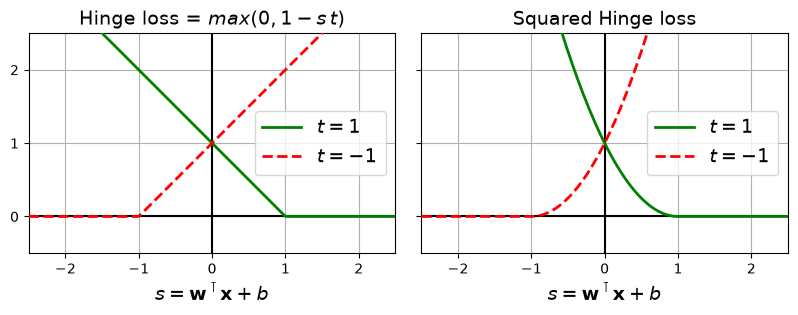

In [26]:
s = np.linspace(-2.5, 2.5, 200)
hinge_pos = np.where(1 - s < 0, 0, 1 - s)  # max(0, 1 - s)
hinge_neg = np.where(1 + s < 0, 0, 1 + s)  # max(0, 1 + s)

titles = (r"Hinge loss = $max(0, 1 - s\,t)$", "Squared Hinge loss")

fix, axs = plt.subplots(1, 2, sharey=True, figsize=(8.2, 3))

for ax, loss_pos, loss_neg, title in zip(
        axs, (hinge_pos, hinge_pos ** 2), (hinge_neg, hinge_neg ** 2), titles):
    ax.plot(s, loss_pos, "g-", linewidth=2, zorder=10, label="$t=1$")
    ax.plot(s, loss_neg, "r--", linewidth=2, zorder=10, label="$t=-1$")
    ax.grid(True)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.set_xlabel(r"$s = \mathbf{w}^\intercal \mathbf{x} + b$")
    ax.axis([-2.5, 2.5, -0.5, 2.5])
    ax.legend(loc="center right")
    ax.set_title(title)
    ax.set_yticks(np.arange(0, 2.5, 1))
    ax.set_aspect("equal")

save_fig("hinge_plot")
plt.show()

양성 클래스 샘플 $\mathbf{x}$가 주어졌을때 ($t=1$) 결정 함수의 출력 $s(w=\mathbf{w}^{\top})\mathbf{x}+b$가 1보다 크면 손실은 0이됨. 이는 샘플이 도로에서 벗어나 양성 클래스쪽에 있는 경우임. 

음성 클래스 샘플( $t = -1$)이 주어졌을때는 $s \leq -1$ 이면 손실이 0임. ㅣㅇ느 샘프링 도로에서 벗어나 음성 클래스 쪽에 있는 경우임.

샘플이 마진에서 반대로 멀어질수록 손실이 커짐. 힌지 손실의 경우 선형적으로, 제곱 힌지 손실이경우 이차 방정식으로 증가됨. 따라서 제곱 힌지 손실은 이상치에 더 민감하게 반응함. 그러나 데이터셋에 이상치가 없는 경우 더 빨리 수렴하는 경향이 있음.

기본적으로 LinearSVC는 제곱된 힌지 손실을 사용하는 반면 SGDClassifier는 힌지 손실을 사용함. 두 클래스 모두 loss 하이퍼파라미터를 "hinge"또는 "squared_hinge"로 설정하여 손실을 선책할 수 있음. SVC 클래스의 최적화 알고리즘은 힌지 손실을 최소화 하는 것과 유사항 솔루션을 찾아내는 것.

# 쌍대 문제

**원 문제(primal problem)** 라고 하는 제약이 있는 최적화 문제가 주어지면 **쌍대 문제(dual problem)** 라고 하는 깊게 관련된 다른 문제로 표현가능. 일반적으로 쌍대문제의 해는 원문제의 하한값이지만 어떤 조건에선 같을 수 있음. SVM은 이 조건을 만족함.

선형 SVM 목적 함수의 쌍대 형식:
$$
\underset{\alpha}{\mathrm{minimize}} 
\frac{1}{2} 
\sum_{i=1}^{m}
\sum_{j=1}^{m}
\alpha^{(i)} \alpha^{(j)}
t^{(i)} t^{(j)}
\mathbf{x}^{(i)^{\top}} \mathbf{x}^{(j)}
-
\sum_{i=1}^{m}
\alpha^{(i)}
$$
[조건] $i=1,2,\cdots,m$ 에 대해서 $\alpha^{(i)} \geq 0$이고 $\sum_{i=1}^{m} \alpha^{(i)} t^{(i)} = 0$

QP 솔버를 통해 이 식으 ㄹ최소화 하는 벡터 $\hat{\alpha}$을 찾았다면 원 문제의 식을 최소화 하는  $\hat{\mathbf{w}}$과 $\hat{b}$을 계산할 수 있음. 이 식에서 $n_s$는 서포트 벡터의 개수를 나타냄.
$$
\hat{\mathbf{w}} = \sum_{i=1}^{m} \hat{\alpha}^{(i)} t^{(i)} \mathbf{x}^{(i)}
$$

$$
\hat{b} =\frac{1}{n_s} \underset{\hat{\alpha}^{(i)} > 0} {\sum_{i=1}^{m}} 
 \big(t^{(i)} - \hat{\mathbf{w}}^{\top} \mathbf{x^{(i)}}\big)
$$

훈려 샘플 수가 특성의 개수보다 작을 떄 원 문제보다 쌍대 문제를 푸는 것이 더 빠름. 더 중요한 것은 원 문에서는 적용이 안되는 커널 트릭이 가능하다는 것임.

## 커널 SVM

(moons 데이터셋 같은) 2차원 데이터셋에 2차 다항식 변환을 적용하고 선형 SVM 분류기를 변환된 이 훈련 세트에 적용했다고 생각해봤을떄 우리가 적용하고자 하는 2차 다항식 매핑 함수 $\phi$

2차 다항식 매핑:
$$

\phi(\mathbf{x})
=
\phi\left(
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
\right)
=
\begin{bmatrix}
x_1^2 \\
\sqrt{2}\,x_1x_2 \\
x_2^2
\end{bmatrix}
$$




변환된 벡터는 2차원이 아닌 3차원이 됨. 두 개의 2차원 벡터 $\boldsymbol{a}$와 $\boldsymbol{b}$에 2차 다항식 매핑을 적용한 다음 변환된 벡터로 점곱을 하면 변환된 벡터의 점곱이 원래의 점곱의 제곱과 같음.

2차 다항식 매핑을 위한 커널 트릭 :
$$
\phi(\boldsymbol{a})^{\top} \phi(\boldsymbol{b})
= \begin{pmatrix}
a_1^2 \\
\sqrt{2}a_1 a_2 \\
a_2^2
\end{pmatrix}^{\top}

\begin{pmatrix}
b_1^2 \\
\sqrt{2}b_1 b_2 \\
b_2^2
\end{pmatrix}
= a_1^2 b_1^2 + 2a_1b_1a_2b_2 + a_2^2b_2^2

\\

= (a_1 b_1 + a_2b_2)^2
=\left(
\begin{pmatrix}
a_1 \\
a_2
\end{pmatrix}^{\top}
\begin{pmatrix}
b_1 \\
b_2
\end{pmatrix}
\right)^2
= (\boldsymbol{a}^{\top}\boldsymbol{a})^2
$$

모든 훈련 샘플에 변환 $\phi$를 적영하면 쌍대 문제(*선형 SVM 목적 함수의 쌍대 형식 식*)에 $\phi(\boldsymbol{a})^{\top} \phi(\boldsymbol{a}) = (\boldsymbol{a}^\top \boldsymbol{b})^2$가 포함됨.  하지만 $\phi$가 2차 다항식 매핑 식에 정의된 2차 다항식 변환이라면 변환된 벡터의 점곱을 간단하게 $(\mathbf{x}^{(i)^{\top}} \mathbf{x}^{(j)})$으로 바꿀수 있음.  그래서 실제 훈련 샘플을 변환할 필요가 전혀 없음. 즉, 쌍대 문제에 있는 점곱으로 바꾸기만 하면 됨. 결과값은 실제로 훈련 샘플을 어렵게 변화해서 선형 SVM 알고리즘을 적용하는 것과 같음.  

하지만 커널트릭이라는 것이 전체 과정에 필욯나 계산량 측면에서 훨씬 효율적임. 함수 $K(\boldsymbol{a,b}) = {(\boldsymbol{a}^{\top},\boldsymbol{b})^2}$을 2차 다항식 커널이라고 부름. 머신러닝에서 **커널** 은 벼호나 $\phi$를 계산하지 않고 원래 벡터 $a$와 $b$에 기반하여 점곱 $\phi(\boldsymbol{a})^{\top} \phi(\boldsymbol{b})$를 계산 할 수 있는 함수임. 

일반적인 커널 :
- 선형 : $K(\boldsymbol{a,b}) = {\boldsymbol{a}^{\top} \boldsymbol{b}}$
- 다항식 : $K(\boldsymbol{a,b}) = (\gamma \boldsymbol{a}^{\top}\boldsymbol{b}+r)^d$
- 가우스 RBF : $K(\boldsymbol{a,b}) = \exp(-\gamma \| \boldsymbol{a} - \boldsymbol{b} \|^2)$
- 시그모이드 : $K(\boldsymbol{a,b}) = \tanh(\gamma \boldsymbol{a}^{\top} \boldsymbol{b} + r)$

쌍대 문제에서 구한 해로원 문제의 해는 선형 SVM 분류기일 경우에는 커널을 사용한다면 결국 예측 식에 $\phi(x^{(i)})$를 호함해야하는데, $\hat{\mathbf{w}}$의 차운이 매우 크거나 무하한 $\phi(x^{(i)})$의 차원과 같아져야 하므로 이를 계산할 수 없음.

그렇다면 $\hat{\mathbf{w}}$을 모른채로 예측을 만들면 됩니다. 다행이도 $\hat{\mathbf{w}}$에 대한 식을 새로운 샘플 $\mathbf{x}^{(n)}$의 결정함수에 적용해서 입력 벡터 간의 점곱으로만된 식을 사용할 수 있게 되어 다음과 같은 식이 완성됨.

커널 SVM 예측하기 : 
$$
h_{\hat{\mathbf{w}} \hat{b}}(\phi(\mathbf{x}^{(n)}))
= \hat{\mathbf{w}}^{\top} \phi(\mathbf{x}^{(n)}) + \hat{b}
= \left( \sum_{i=1}^{m} \hat{\alpha}^{(i)} t^{(i)} \phi(\mathbf{x}^{(i)}) \right)^{\top} \phi(\mathbf{x}^{(n)})+ \hat{b} \\
= \sum_{i=1}^{m} \hat{\alpha}^{(i)} t^{(i)} \left( \phi(\mathbf{x}^{(i)})^{\top}  \phi(\mathbf{x}^{(n)}) \right) + \hat{b} \\
= \underset{\hat{a}^{(i)} > 0}{\sum_{i=1}^{m}} \hat{\alpha}^{(i)} t^{(i)} K(\mathbf{x}^{(i)}, \mathbf{x}^{(n)}) + \hat{b}
$$

서포트 벡터만 $\alpha^{i} \neq 0$이기 떄문에 예측을 만들기 위해서는 전체 샘플이 아니라 서포트 백터와 새 입력 벡터 $\mathbf{x}^{(n)}$ 간의 점곱만 계산하면 됨. 물론 $\hat{b}$도 커널 트릭을 사용해 계산해야함

커널 트릭을 사용한 편향 계산 : 
$$
\hat{b} = \frac{1}{n_s} 
\underset{\hat{a}^{(i)} > 0}{\sum_{i=1}^{m}} 
\left( t^{(i)} - \hat{\mathbf{w}}^{\top}  \phi(\mathbf{x}^{(i)}) \right)

= \frac{1}{n_s} \underset{\hat{a}^{(i)} > 0}{\sum_{i=1}^{m}}  \left( t^{(i)} - \left( \sum_{j=1}^{m} \hat{\alpha}^{(j)} t^{(j)} \phi(\mathbf{x}^{(j)}) \right)^{\top} \right) 
\\
= \frac{1}{n_s} \underset{\hat{a}^{(i)} > 0}{\sum_{i=1}^{m}}  \left( t^{(i)} -  \underset{\hat{a}^{(j)} > 0}{\sum_{j=1}^{m}} \hat{\alpha}^{(j)} t^{(j)} K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) \right) 
$$

# 연습 문제

## 서포트 머신 아이디어

서포트 벡터 머신의 기본 아이디어는 무엇인가요 ?

- 답 : 클래스 사이의 마진(margin)을 최대화하는 결정 경계를 찾아 데이터를 분류하는 것